In [2]:
import pypsa
import pandas as pd
import numpy as np
from pathlib import Path

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [49]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT_+0.00.nc',
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT_+0.00.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [66]:
idx = pd.IndexSlice
ex0 = pd.read_csv(
    Path.cwd().parent / 'resources' / 'existing_heating_distribution_base_s_50_2025.csv',
    header=[0,1], index_col=0
)
ex0.T.loc[idx[['residential rural', 'services rural']]].groupby(level=1).sum().T.head()

technology,air heat pump,biomass boiler,gas boiler,ground heat pump,oil boiler,resistive heater
name,,,,,,
AL0 0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
AT0 0,0.0,5076.759168,3891.708788,1077.0,6605.883372,0.000000
BA0 0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
BE0 0,0.0,196.871112,1298.599182,61.0,947.762418,143.628088
BG0 0,0.0,1395.159666,39.196760,45.0,911.324663,847.629929


In [88]:
def get_efficiency(n, link):

    try:
        if link in (effs := n.links_t.efficiency).columns:
            return effs.loc[:, link].mean()
        elif 'CHP' in link:
            return n.links.loc[link, 'efficiency2']
        else:
            return n.links.loc[link, 'efficiency']
    except KeyError:
        return 0.


get_efficiency(n, 'AL0 0 urban central gas CHP')

0.413265306122449

In [85]:
existing = pd.concat([
    ex0.T.loc[idx[['residential rural', 'services rural']]].groupby(level=1).sum().T,
    ex0.T.loc[idx[['residential urban decentral', 'services urban decentral']]].groupby(level=1).sum().T,
],
    axis=1,
    keys=['rural', 'urban decentral']
)
existing.head()

rural                                               \
technology air heat pump biomass boiler   gas boiler ground heat pump   
name                                                                    
AL0 0                0.0       0.000000     0.000000              0.0   
AT0 0                0.0    5076.759168  3891.708788           1077.0   
BA0 0                0.0       0.000000     0.000000              0.0   
BE0 0                0.0     196.871112  1298.599182             61.0   
BG0 0                0.0    1395.159666    39.196760             45.0   

                                         urban decentral                 \
technology   oil boiler resistive heater   air heat pump biomass boiler   
name                                                                      
AL0 0          0.000000         0.000000             0.0       0.000000   
AT0 0       6605.883372         0.000000           720.0    7081.240832   
BA0 0          0.000000         0.000000             0.0       0.000000   
BE0 0        947.762418       143.628088           170.0    4107.128888   
BG0 0        911.324663       847.629929          1010.0    4299.840334   

                                                                          
technology    gas boiler ground heat pump    oil boiler resistive heater  
name                                                                      
AL0 0           0.000000              0.0      0.000000         0.000000  
AT0 0        5428.291212              0.0   9214.116628         0.000000  
BA0 0           0.000000              0.0      0.000000         0.000000  
BE0 0       27091.400818              0.0  19772.237582      2996.371912  
BG0 0         120.803240              0.0   2808.675337      2612.370071

In [115]:
get_efficiency(n, 'AT0 0 urban decentral oil boiler')

0.0

In [118]:
def to_shares(installed):

    p_nom_rural = installed.loc[:, idx['rural']]

    etas = p_nom_rural.apply(
        lambda col: col.index.map(
            lambda idx: get_efficiency(n, idx + ' rural ' + col.name)
            )
    )
    eff_p_nom_rural = p_nom_rural.mul(etas, axis=0).rename(columns={'ground heat pump': 'heat pump'})

    p_nom_decentral = installed.loc[:, idx['urban decentral']]

    etas = p_nom_decentral.apply(
        lambda col: col.index.map(
            lambda idx: get_efficiency(n, idx + ' urban decentral ' + col.name)
            )
    )
    eff_p_nom_decentral = p_nom_decentral.mul(etas, axis=0).rename(columns={'air heat pump': 'heat pump'})

    eff_p_nom_total = eff_p_nom_rural.add(eff_p_nom_decentral, fill_value=0)

    shares = eff_p_nom_total.div(eff_p_nom_total.sum(axis=1), axis=0)

    return shares.loc[:, shares.replace(np.nan, 0).sum() > 0]


shares = to_shares(existing)

In [124]:
shares.mean().mul(100).astype(int)

technology
biomass boiler    29
gas boiler        47
heat pump         22
dtype: int64

In [122]:
import pandas as pd

tyndp_heating = pd.DataFrame(
    {
        ("Reference", "2019"): {"Hybrid heat pump": 0.02,  "Electric heat pump": 0.13, "Methane boiler": 0.37, "Hydrogen boiler": 0.00, "Other technologies": 0.48},
        ("Distributed Energy", "2040"): {"Hybrid heat pump": 0.05,  "Electric heat pump": 0.50, "Methane boiler": 0.12, "Hydrogen boiler": 0.02, "Other technologies": 0.31},
        ("Distributed Energy", "2050"): {"Hybrid heat pump": 0.07,  "Electric heat pump": 0.63, "Methane boiler": 0.03,  "Hydrogen boiler": 0.03, "Other technologies": 0.25},
        ("Global Ambition", "2040"): {"Hybrid heat pump": 0.11, "Electric heat pump": 0.37, "Methane boiler": 0.14, "Hydrogen boiler": 0.05, "Other technologies": 0.33},
        ("Global Ambition", "2050"): {"Hybrid heat pump": 0.13, "Electric heat pump": 0.50, "Methane boiler": 0.05,  "Hydrogen boiler": 0.05, "Other technologies": 0.28},
    }
).mul(100)

tyndp_heating.columns = pd.MultiIndex.from_tuples(
    tyndp_heating.columns, names=["Scenario", "Year"]
    )
tyndp_heating.index.name = "Technology"

tyndp_heating

Scenario           Reference Distributed Energy       Global Ambition      
Year                    2019               2040  2050            2040  2050
Technology                                                                 
Hybrid heat pump         2.0                5.0   7.0            11.0  13.0
Electric heat pump      13.0               50.0  63.0            37.0  50.0
Methane boiler          37.0               12.0   3.0            14.0   5.0
Hydrogen boiler          0.0                2.0   3.0             5.0   5.0
Other technologies      48.0               31.0  25.0            33.0  28.0

In [131]:
year = 2035

current_gas_share = shares.loc['GB2 0', 'gas boiler'] * 100
target_2040 = tyndp_heating.loc['Methane boiler', ('Distributed Energy', '2040')]

year_target = (year - 2024) / (2040 - 2024) * (target_2040 - current_gas_share) + current_gas_share
year_target

38.42350364692851

#### Implementation

In [145]:
import pypsa
import pandas as pd


n = pypsa.Network()

snapshots = pd.date_range("2030-01-01", periods=1, freq="H")
n.set_snapshots(snapshots)

n.add("Bus", "heat")
n.add("Bus", "gas")
n.add("Bus", "electricity")

n.add("Load", "heat_demand", bus="heat", p_set=60.0)

n.add(
    "Generator",
    "gas_supply",
    bus="gas",
    p_nom_extendable=True,
    marginal_cost=25.0,
)

n.add(
    "Generator",
    "grid",
    bus="electricity",
    p_nom_extendable=True,
    marginal_cost=40.0,
)

n.add(
    "Link",
    "heat_pump",
    bus0="electricity",
    bus1="heat",
    efficiency=3.0,
    p_nom_extendable=True,
    capital_cost=50_000.0,
)

BASELINE_BOILER = 80.0

n.add(
    "Link",
    "gas_boiler",
    bus0="gas",
    bus1="heat",
    efficiency=0.9,
    p_nom_extendable=True,
    p_nom_max=BASELINE_BOILER,
    capital_cost=20_000.0,
)


def extra_functionality(n: pypsa.Network, snapshots: pd.DatetimeIndex) -> None:
    gamma = 200

    x = n.model["Link-p_nom"].loc["gas_boiler"]

    penalty = 0.5 * gamma * (x**2 -2 * x * BASELINE_BOILER) + 0

    base_obj = n.model.objective.expression
    n.model.add_objective(base_obj + penalty, overwrite=True, sense="min")


status, condition = n.optimize(
    solver_name="gurobi",
    extra_functionality=extra_functionality,
)

print("status:", status, "condition:", condition)
print("\nOptimal capacities (MW_th):")
print("  gas_boiler p_nom_opt =", float(n.links.at["gas_boiler", "p_nom_opt"]))
print("  heat_pump  p_nom_opt =", float(n.links.at["heat_pump", "p_nom_opt"]))
print("\nObjective value:", n.objective)


/tmp/ipykernel_469508/3669506906.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  snapshots = pd.date_range("2030-01-01", periods=1, freq="H")
Index(['heat_pump', 'gas_boiler'], dtype='object', name='Link')
Index(['heat', 'gas', 'electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.04s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2762156


INFO:gurobipy:Set parameter LicenseID to value 2762156


...

INFO:gurobipy:Barrier solved model in 8 iterations and 0.04 seconds (0.00 work units)


Optimal objective 6.99014578e+05


INFO:gurobipy:Optimal objective 6.99014578e+05


INFO:gurobipy:
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 8 primals, 16 duals
Objective: 6.99e+05
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


status: ok condition: optimal

Optimal capacities (MW_th):
  gas_boiler p_nom_opt = 54.935000000373506
  heat_pump  p_nom_opt = 3.5194999998940553

Objective value: 699014.5775003051


#### Test in the model

In [149]:
caps = pd.read_csv(
    Path.cwd().parent / 'resources' / 'gas_heating_progress_factors_base_s_50__168H-T-H-B-I-A-dist1_2035_NT_3000.csv',
    index_col=0
)
caps.head()

,rural,urban decentral
name,,
AT0 0,2094.991953,2922.167878
BE0 0,529.611338,11048.761803
BG0 0,179.001249,551.676492
CH0 0,0.000000,0.000000
CZ0 0,1180.974272,3215.980276


In [197]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT_3000.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


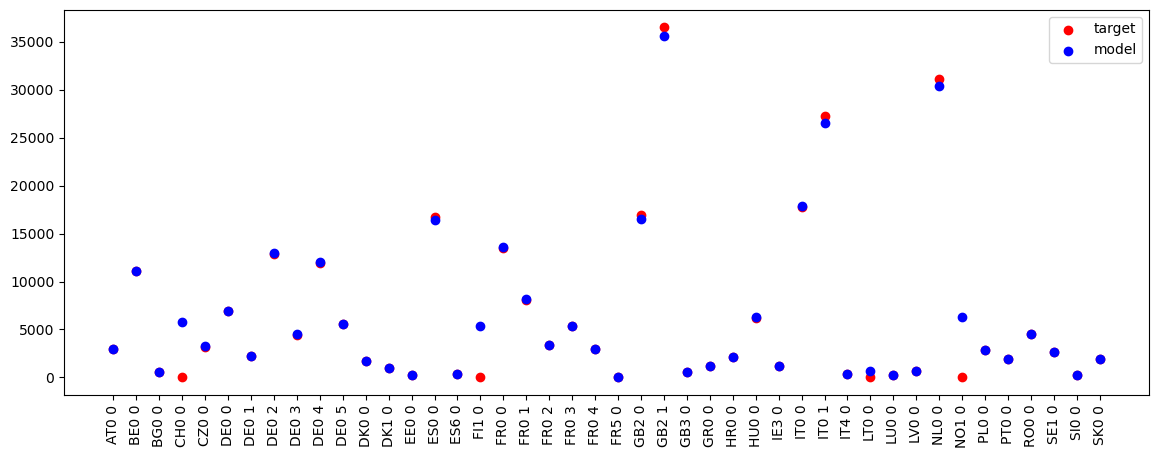

In [198]:
import matplotlib.pyplot as plt

context = 'urban decentral'

fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(range(len(caps)), caps[context], color='red', label='target')
ax.scatter(range(len(caps)), n.links.loc[caps.index + f' {context} gas boiler', 'p_nom_opt'], color='blue', label='model')

ax.set_xticks(range(len(caps)))
ax.set_xticklabels(caps.index, rotation=90)

ax.legend()

plt.show()

<Axes: xlabel='snapshot'>

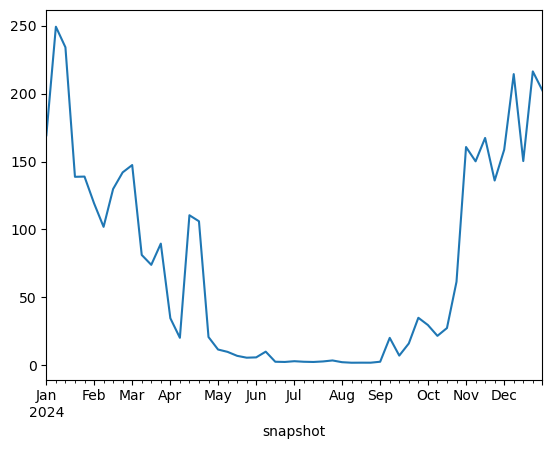

In [199]:
(n.links_t.p0.loc[:, caps.index + f' {context} gas boiler'].sum(axis=1) / 1e3).plot()

<Axes: xlabel='snapshot'>

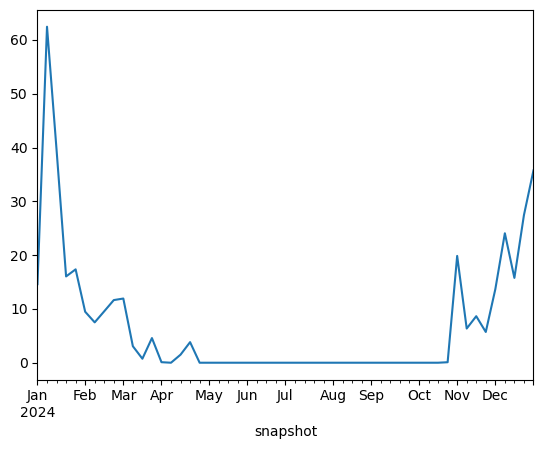

In [196]:
(n.links_t.p0.loc[:, caps.index + f' {context} gas boiler'].sum(axis=1) / 1e3).plot()

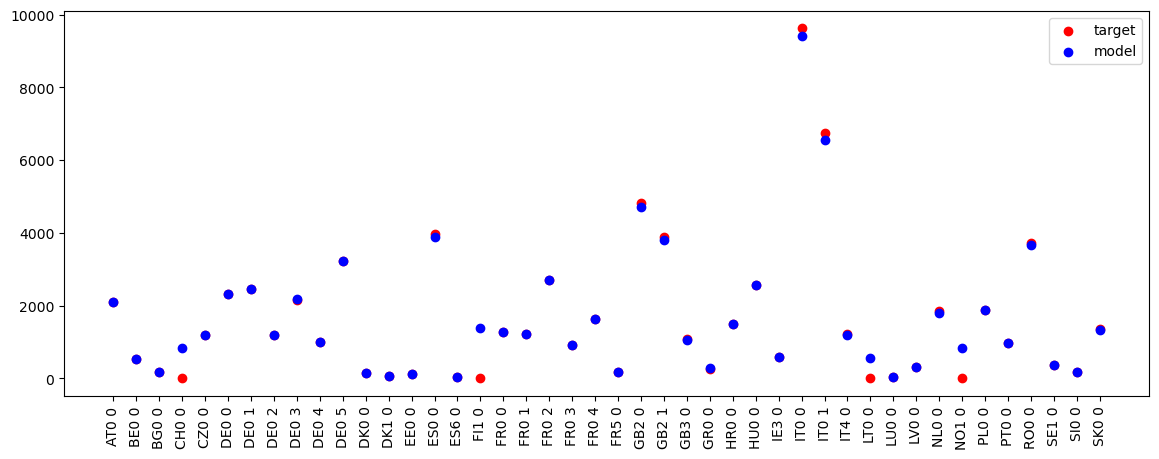

In [191]:
import matplotlib.pyplot as plt

context = 'rural'

fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(range(len(caps)), caps[context], color='red', label='target')
ax.scatter(range(len(caps)), n.links.loc[caps.index + f' {context} gas boiler', 'p_nom_opt'], color='blue', label='model')

ax.set_xticks(range(len(caps)))
ax.set_xticklabels(caps.index, rotation=90)

ax.legend()

plt.show()

In [186]:
print(n.links.loc[caps.index + f' {context} gas boiler', 'p_nom_opt'].head())

name
AT0 0 urban decentral gas boiler     2955.441997
BE0 0 urban decentral gas boiler    11139.633614
BG0 0 urban decentral gas boiler      554.597963
CH0 0 urban decentral gas boiler     5474.230119
CZ0 0 urban decentral gas boiler     3248.196803
Name: p_nom_opt, dtype: float64


In [183]:
print(n.links.loc[caps.index + f' {context} gas boiler', 'p_nom_opt'].head())

name
AT0 0 urban decentral gas boiler     2949.887559
BE0 0 urban decentral gas boiler    11141.989917
BG0 0 urban decentral gas boiler      555.263719
CH0 0 urban decentral gas boiler     5430.322881
CZ0 0 urban decentral gas boiler     3255.105131
Name: p_nom_opt, dtype: float64


In [166]:
n.generators.loc[n.generators.carrier == 'co2-ets', 'marginal_cost']

Generator
eu_ets   -79.989254
uk_ets   -53.990785
Name: marginal_cost, dtype: float64